Linearni klasifikator

In [ ]:
# step_00_download_and_inspect.py
# Dimenzija slika je 320x240
!pip install kagglehub pillow

from pathlib import Path
from collections import Counter

import kagglehub
from PIL import Image


DATASET_ID = "paultimothymooney/blood-cells"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


def find_image_files(root):
    root = Path(root)
    return [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]


def print_tree(root, max_depth=4):
    root = Path(root)
    print(f"\nDataset root:\n{root}\n")

    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue

        indent = "    " * (depth - 1)
        marker = "[DIR]" if path.is_dir() else "[FILE]"
        print(f"{indent}{marker} {path.name}")


def summarize_by_parent_folder(image_paths):
    counts = Counter(p.parent.name for p in image_paths)

    print("\nImage count by immediate parent folder:")
    for folder_name, count in counts.most_common():
        print(f"{folder_name:20s} {count}")


def get_image_dimensions(image_paths):
    dimensions = {}
    broken_images = []

    for path in image_paths:
        try:
            with Image.open(path) as img:
                dimensions[path] = img.size
        except Exception:
            broken_images.append(path)

    return dimensions, broken_images


def print_image_dimensions(dimensions):
    print("\nImage dimensions:")
    for path, (width, height) in dimensions.items():
        print(f"{path} -> {width}x{height}")


def summarize_dimensions(dimensions):
    dimension_counts = Counter(dimensions.values())

    print("\nImage count by dimensions:")
    for size, count in dimension_counts.most_common():
        width, height = size
        print(f"{str(width) + 'x' + str(height):15s} {count}")


def summarize_by_class_and_dimensions(dimensions):
    counts = Counter((path.parent.name, size) for path, size in dimensions.items())

    print("\nImage count by class and dimensions:")
    for (class_name, (width, height)), count in counts.most_common():
        print(f"{class_name:20s} {width}x{height:<8} {count}")


def main():
    dataset_path = kagglehub.dataset_download(DATASET_ID)
    dataset_path = Path(dataset_path)

    print_tree(dataset_path, max_depth=4)

    image_paths = find_image_files(dataset_path)

    print(f"\nTotal image files found: {len(image_paths)}")

    summarize_by_parent_folder(image_paths)

    dimensions, broken_images = get_image_dimensions(image_paths)

    print(f"\nReadable images: {len(dimensions)}")
    print(f"Broken/unreadable images: {len(broken_images)}")

    print_image_dimensions(dimensions)
    summarize_dimensions(dimensions)
    summarize_by_class_and_dimensions(dimensions)

    if broken_images:
        print("\nBroken/unreadable image paths:")
        for path in broken_images:
            print(path)

    print("\nFirst 10 image paths:")
    for path in image_paths[:10]:
        print(path)


if __name__ == "__main__":
    main()

In [ ]:
from pathlib import Path
from collections import Counter

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


DATASET_ROOT = Path("/root/.cache/kagglehub/datasets/paultimothymooney/blood-cells/versions/6/dataset2-master/dataset2-master/images")


TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"
TEST_SIMPLE_DIR = DATASET_ROOT / "TEST_SIMPLE"

IMG_SIZE = 64
BATCH_SIZE = 32
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)


def count_images_by_class(folder):
    counts = {}

    for class_dir in sorted(folder.iterdir()):
        if class_dir.is_dir():
            image_count = len(list(class_dir.glob("*")))
            counts[class_dir.name] = image_count

    return counts


def print_counts(title, counts):
    print(title)
    print("-" * len(title))

    total = sum(counts.values())

    for class_name, count in counts.items():
        percentage = count / total * 100
        print(f"{class_name:12s}: {count:5d} images ({percentage:5.2f}%)")

    print(f"{'TOTAL':12s}: {total:5d} images\n")


train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

print_counts("TRAIN SET", train_counts)
print_counts("TEST SET", test_counts)

print("Dataset root exists:", DATASET_ROOT.exists())
print("Train dir exists:", TRAIN_DIR.exists())
print("Test dir exists:", TEST_DIR.exists())

TRAIN SET
---------
EOSINOPHIL  :  2497 images (25.08%)
LYMPHOCYTE  :  2483 images (24.94%)
MONOCYTE    :  2478 images (24.89%)
NEUTROPHIL  :  2499 images (25.10%)
TOTAL       :  9957 images

TEST SET
--------
EOSINOPHIL  :   623 images (25.05%)
LYMPHOCYTE  :   620 images (24.93%)
MONOCYTE    :   620 images (24.93%)
NEUTROPHIL  :   624 images (25.09%)
TOTAL       :  2487 images

Dataset root exists: True
Train dir exists: True
Test dir exists: True


In [ ]:
# step_00_download_and_inspect.py
# Dimenzija slika je 320x240
!pip install kagglehub pillow

from pathlib import Path
from collections import Counter

import kagglehub
from PIL import Image


DATASET_ID = "paultimothymooney/blood-cells"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


def find_image_files(root):
    root = Path(root)
    return [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]


def print_tree(root, max_depth=4):
    root = Path(root)
    print(f"\nDataset root:\n{root}\n")

    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue

        indent = "    " * (depth - 1)
        marker = "[DIR]" if path.is_dir() else "[FILE]"
        print(f"{indent}{marker} {path.name}")


def summarize_by_parent_folder(image_paths):
    counts = Counter(p.parent.name for p in image_paths)

    print("\nImage count by immediate parent folder:")
    for folder_name, count in counts.most_common():
        print(f"{folder_name:20s} {count}")


def get_image_dimensions(image_paths):
    dimensions = {}
    broken_images = []

    for path in image_paths:
        try:
            with Image.open(path) as img:
                dimensions[path] = img.size
        except Exception:
            broken_images.append(path)

    return dimensions, broken_images


def print_image_dimensions(dimensions):
    print("\nImage dimensions:")
    for path, (width, height) in dimensions.items():
        print(f"{path} -> {width}x{height}")


def summarize_dimensions(dimensions):
    dimension_counts = Counter(dimensions.values())

    print("\nImage count by dimensions:")
    for size, count in dimension_counts.most_common():
        width, height = size
        print(f"{str(width) + 'x' + str(height):15s} {count}")


def summarize_by_class_and_dimensions(dimensions):
    counts = Counter((path.parent.name, size) for path, size in dimensions.items())

    print("\nImage count by class and dimensions:")
    for (class_name, (width, height)), count in counts.most_common():
        print(f"{class_name:20s} {width}x{height:<8} {count}")


def main():
    dataset_path = kagglehub.dataset_download(DATASET_ID)
    dataset_path = Path(dataset_path)

    print_tree(dataset_path, max_depth=4)

    image_paths = find_image_files(dataset_path)

    print(f"\nTotal image files found: {len(image_paths)}")

    summarize_by_parent_folder(image_paths)

    dimensions, broken_images = get_image_dimensions(image_paths)

    print(f"\nReadable images: {len(dimensions)}")
    print(f"Broken/unreadable images: {len(broken_images)}")

    print_image_dimensions(dimensions)
    summarize_dimensions(dimensions)
    summarize_by_class_and_dimensions(dimensions)

    if broken_images:
        print("\nBroken/unreadable image paths:")
        for path in broken_images:
            print(path)

    print("\nFirst 10 image paths:")
    for path in image_paths[:10]:
        print(path)


if __name__ == "__main__":
    main()

In [ ]:
# step_00_download_and_inspect.py
# Dimenzija slika je 320x240
!pip install kagglehub pillow

from pathlib import Path
from collections import Counter

import kagglehub
from PIL import Image


DATASET_ID = "paultimothymooney/blood-cells"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


def find_image_files(root):
    root = Path(root)
    return [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]


def print_tree(root, max_depth=4):
    root = Path(root)
    print(f"\nDataset root:\n{root}\n")

    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue

        indent = "    " * (depth - 1)
        marker = "[DIR]" if path.is_dir() else "[FILE]"
        print(f"{indent}{marker} {path.name}")


def summarize_by_parent_folder(image_paths):
    counts = Counter(p.parent.name for p in image_paths)

    print("\nImage count by immediate parent folder:")
    for folder_name, count in counts.most_common():
        print(f"{folder_name:20s} {count}")


def get_image_dimensions(image_paths):
    dimensions = {}
    broken_images = []

    for path in image_paths:
        try:
            with Image.open(path) as img:
                dimensions[path] = img.size
        except Exception:
            broken_images.append(path)

    return dimensions, broken_images


def print_image_dimensions(dimensions):
    print("\nImage dimensions:")
    for path, (width, height) in dimensions.items():
        print(f"{path} -> {width}x{height}")


def summarize_dimensions(dimensions):
    dimension_counts = Counter(dimensions.values())

    print("\nImage count by dimensions:")
    for size, count in dimension_counts.most_common():
        width, height = size
        print(f"{str(width) + 'x' + str(height):15s} {count}")


def summarize_by_class_and_dimensions(dimensions):
    counts = Counter((path.parent.name, size) for path, size in dimensions.items())

    print("\nImage count by class and dimensions:")
    for (class_name, (width, height)), count in counts.most_common():
        print(f"{class_name:20s} {width}x{height:<8} {count}")


def main():
    dataset_path = kagglehub.dataset_download(DATASET_ID)
    dataset_path = Path(dataset_path)

    print_tree(dataset_path, max_depth=4)

    image_paths = find_image_files(dataset_path)

    print(f"\nTotal image files found: {len(image_paths)}")

    summarize_by_parent_folder(image_paths)

    dimensions, broken_images = get_image_dimensions(image_paths)

    print(f"\nReadable images: {len(dimensions)}")
    print(f"Broken/unreadable images: {len(broken_images)}")

    print_image_dimensions(dimensions)
    summarize_dimensions(dimensions)
    summarize_by_class_and_dimensions(dimensions)

    if broken_images:
        print("\nBroken/unreadable image paths:")
        for path in broken_images:
            print(path)

    print("\nFirst 10 image paths:")
    for path in image_paths[:10]:
        print(path)


if __name__ == "__main__":
    main()

# Image count by dimensions:
#320x240         12515
#640x480         366

#Image count by class and dimensions:
#NEUTROPHIL           320x240      3171
#EOSINOPHIL           320x240      3133
#LYMPHOCYTE           320x240      3109
#MONOCYTE             320x240      3102

In [ ]:
# step_00_download_and_inspect.py
!pip install kagglehub

from pathlib import Path
from collections import Counter

import kagglehub


DATASET_ID = "paultimothymooney/blood-cells"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


def find_image_files(root):
    root = Path(root)
    return [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]


def print_tree(root, max_depth=4):
    root = Path(root)
    print(f"\nDataset root:\n{root}\n")

    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue

        indent = "    " * (depth - 1)
        marker = "[DIR]" if path.is_dir() else "[FILE]"
        print(f"{indent}{marker} {path.name}")


def summarize_by_parent_folder(image_paths):
    counts = Counter(p.parent.name for p in image_paths)

    print("\nImage count by immediate parent folder:")
    for folder_name, count in counts.most_common():
        print(f"{folder_name:20s} {count}")


def main():
    dataset_path = kagglehub.dataset_download(DATASET_ID)
    dataset_path = Path(dataset_path)

    print_tree(dataset_path, max_depth=4)

    image_paths = find_image_files(dataset_path)

    print(f"\nTotal image files found: {len(image_paths)}")
    summarize_by_parent_folder(image_paths)

    print("\nFirst 10 image paths:")
    for path in image_paths[:10]:
        print(path)


if __name__ == "__main__":
    main()

100%|██████████| 108M/108M [00:01<00:00, 90.4MB/s]

Extracting files...



Dataset root:
/root/.cache/kagglehub/datasets/paultimothymooney/blood-cells/versions/6

[DIR] dataset-master
    [DIR] dataset-master
        [DIR] Annotations
            [FILE] BloodImage_00000.xml
            [FILE] BloodImage_00001.xml
            [FILE] BloodImage_00002.xml
            [FILE] BloodImage_00003.xml
            [FILE] BloodImage_00004.xml
            [FILE] BloodImage_00005.xml
            [FILE] BloodImage_00006.xml
            [FILE] BloodImage_00007.xml
            [FILE] BloodImage_00008.xml
            [FILE] BloodImage_00009.xml
            [FILE] BloodImage_00010.xml
            [FILE] BloodImage_00011.xml
            [FILE] BloodImage_00012.xml
            [FILE] BloodImage_00013.xml
            [FILE] BloodImage_00014.xml
            [FILE] BloodImage_00015.xml
            [FILE] BloodImage_00016.xml
            [FILE] BloodImage_00017.xml
            [FILE] BloodImage_00018.xml
            [FILE] BloodImage_00019.xml
            [FILE] BloodImage_00020.xml

In [ ]:
# step_00_download_and_inspect.py
!pip install kagglehub

from pathlib import Path
from collections import Counter

import kagglehub


DATASET_ID = "paultimothymooney/blood-cells"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


def find_image_files(root):
    root = Path(root)
    return [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]


def print_tree(root, max_depth=4):
    root = Path(root)
    print(f"\nDataset root:\n{root}\n")

    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue

        indent = "    " * (depth - 1)
        marker = "[DIR]" if path.is_dir() else "[FILE]"
        print(f"{indent}{marker} {path.name}")


def summarize_by_parent_folder(image_paths):
    counts = Counter(p.parent.name for p in image_paths)

    print("\nImage count by immediate parent folder:")
    for folder_name, count in counts.most_common():
        print(f"{folder_name:20s} {count}")


def main():
    dataset_path = kagglehub.dataset_download(DATASET_ID)
    dataset_path = Path(dataset_path)

    print_tree(dataset_path, max_depth=4)

    image_paths = find_image_files(dataset_path)

    print(f"\nTotal image files found: {len(image_paths)}")
    summarize_by_parent_folder(image_paths)

    print("\nFirst 10 image paths:")
    for path in image_paths[:10]:
        print(path)


if __name__ == "__main__":
    main()

100%|██████████| 108M/108M [00:01<00:00, 90.4MB/s]

Extracting files...



Dataset root:
/root/.cache/kagglehub/datasets/paultimothymooney/blood-cells/versions/6

[DIR] dataset-master
    [DIR] dataset-master
        [DIR] Annotations
            [FILE] BloodImage_00000.xml
            [FILE] BloodImage_00001.xml
            [FILE] BloodImage_00002.xml
            [FILE] BloodImage_00003.xml
            [FILE] BloodImage_00004.xml
            [FILE] BloodImage_00005.xml
            [FILE] BloodImage_00006.xml
            [FILE] BloodImage_00007.xml
            [FILE] BloodImage_00008.xml
            [FILE] BloodImage_00009.xml
            [FILE] BloodImage_00010.xml
            [FILE] BloodImage_00011.xml
            [FILE] BloodImage_00012.xml
            [FILE] BloodImage_00013.xml
            [FILE] BloodImage_00014.xml
            [FILE] BloodImage_00015.xml
            [FILE] BloodImage_00016.xml
            [FILE] BloodImage_00017.xml
            [FILE] BloodImage_00018.xml
            [FILE] BloodImage_00019.xml
            [FILE] BloodImage_00020.xml

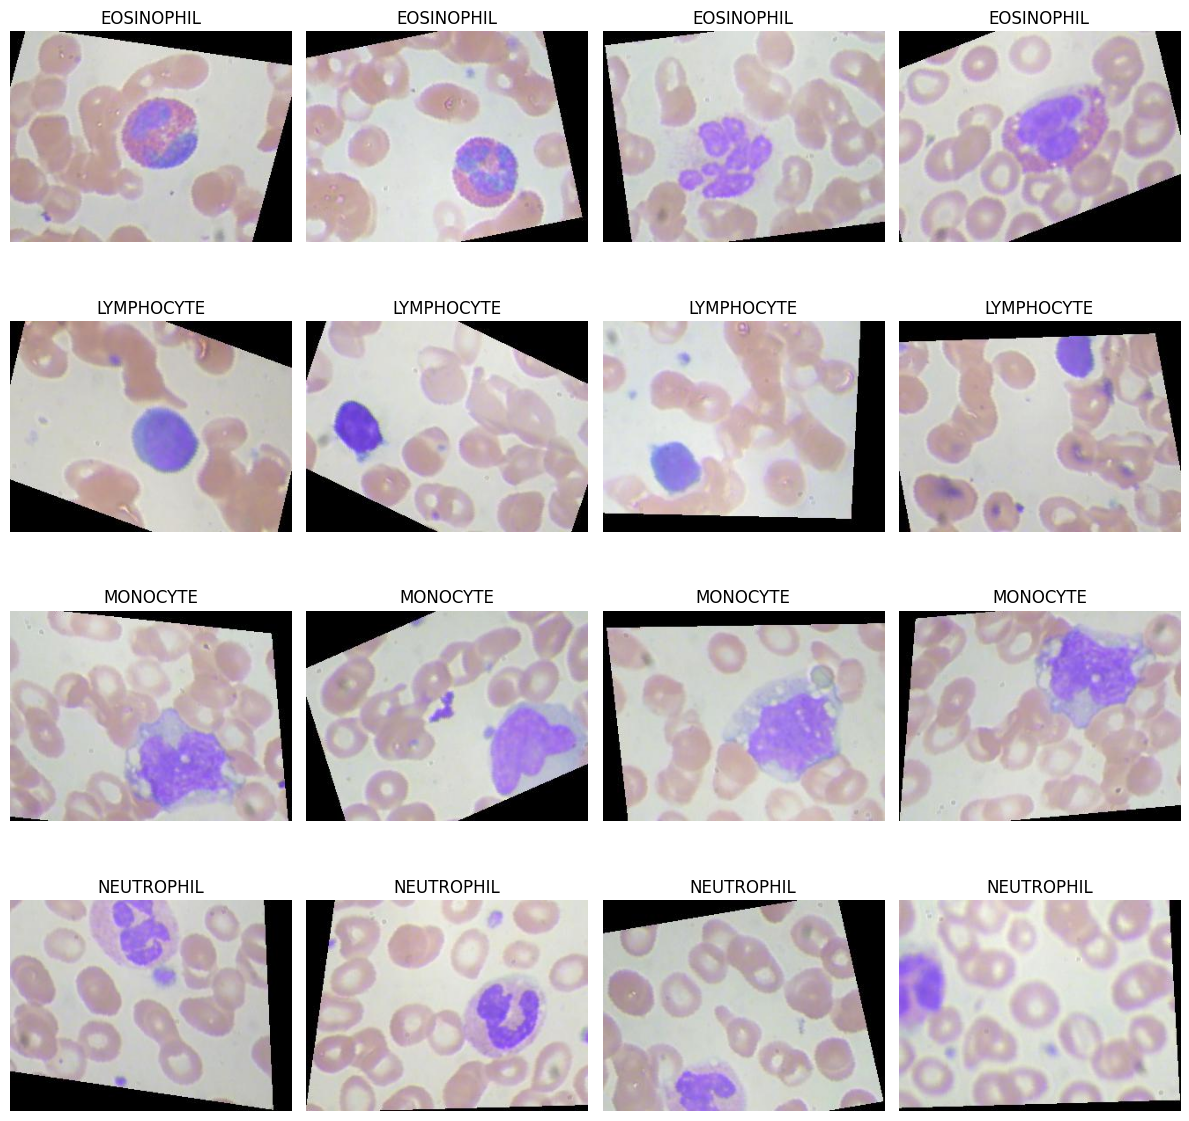

In [ ]:
def show_sample_images(folder, samples_per_class=4):
    class_dirs = [p for p in sorted(folder.iterdir()) if p.is_dir()]

    rows = len(class_dirs)
    cols = samples_per_class

    plt.figure(figsize=(cols * 3, rows * 3))

    plot_idx = 1

    for class_dir in class_dirs:
        image_paths = sorted(list(class_dir.glob("*")))[:samples_per_class]

        for image_path in image_paths:
            image = Image.open(image_path).convert("RGB")

            plt.subplot(rows, cols, plot_idx)
            plt.imshow(image)
            plt.title(class_dir.name)
            plt.axis("off")

            plot_idx += 1

    plt.tight_layout()
    plt.show()


show_sample_images(TRAIN_DIR, samples_per_class=4)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())

Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Class to index: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}
Train samples: 9957
Test samples: 2487
Batch image shape: torch.Size([32, 3, 64, 64])
Batch label shape: torch.Size([32])
Min pixel value: 0.0
Max pixel value: 0.9686274528503418


In [ ]:
def majority_baseline_accuracy(train_dataset, test_dataset):
    train_labels = [label for _, label in train_dataset.samples]
    test_labels = [label for _, label in test_dataset.samples]

    majority_class = Counter(train_labels).most_common(1)[0][0]

    correct = sum(label == majority_class for label in test_labels)
    accuracy = correct / len(test_labels)

    idx_to_class = {idx: class_name for class_name, idx in train_dataset.class_to_idx.items()}

    print("Majority class:", idx_to_class[majority_class])
    print(f"Majority baseline accuracy: {accuracy:.4f}")


majority_baseline_accuracy(train_dataset, test_dataset)

'''
Prije treniranja bilo kakvog modela trebalo je provjeriti koliko bi sustav bio uspješan da uopće ne uči značajke slika, nego samo uvijek predviđa najčešću klasu iz trening skupa. Zato je izračunata većinska klasa u train_datasetu, a zatim je ta ista klasa korištena kao predikcija za sve slike u testnom skupu.

Dobiveni rezultat pokazuje da je najčešća klasa NEUTROPHIL, a accuracy takvog trivijalnog pristupa iznosi 0.2509, odnosno približno 25%. To je očekivano jer dataset ima četiri klase i relativno je uravnotežen, pa nasumično ili većinsko pogađanje daje rezultat oko jedne četvrtine.

Ovaj korak je važan jer postavlja donju granicu performansi. Svaki smisleni model mora značajno nadmašiti ovaj rezultat; u suprotnom ne bi učio korisne vizualne obrasce, nego bi bio praktički beskoristan classifier.
'''

Majority class: NEUTROPHIL
Majority baseline accuracy: 0.2509


'\nPrije treniranja bilo kakvog modela trebalo je provjeriti koliko bi sustav bio uspješan da uopće ne uči značajke slika, nego samo uvijek predviđa najčešću klasu iz trening skupa. Zato je izračunata većinska klasa u train_datasetu, a zatim je ta ista klasa korištena kao predikcija za sve slike u testnom skupu.\n\nDobiveni rezultat pokazuje da je najčešća klasa NEUTROPHIL, a accuracy takvog trivijalnog pristupa iznosi 0.2509, odnosno približno 25%. To je očekivano jer dataset ima četiri klase i relativno je uravnotežen, pa nasumično ili većinsko pogađanje daje rezultat oko jedne četvrtine.\n\nOvaj korak je važan jer postavlja donju granicu performansi. Svaki smisleni model mora značajno nadmašiti ovaj rezultat; u suprotnom ne bi učio korisne vizualne obrasce, nego bi bio praktički beskoristan classifier.\n'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm.auto import tqdm


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE
NUM_CLASSES = len(train_dataset.classes)

EPOCHS = 10
LR = 1e-3


class LinearClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.classifier(x)
        return x


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds


linear_model = LinearClassifier(INPUT_DIM, NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(linear_model.parameters(), lr=LR)

print("Device:", DEVICE)
print(linear_model)

history_linear = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        linear_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_acc, y_true_linear, y_pred_linear = evaluate(
        linear_model,
        test_loader,
        criterion,
        DEVICE
    )

    history_linear["train_loss"].append(train_loss)
    history_linear["train_acc"].append(train_acc)
    history_linear["test_loss"].append(test_loss)
    history_linear["test_acc"].append(test_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Device: cuda
LinearClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Linear(in_features=12288, out_features=4, bias=True)
)


Training:   0%|          | 0/312 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch [1/10] Train Loss: 1.7998 | Train Acc: 0.2581 | Test Loss: 1.4898 | Test Acc: 0.2887


Training:   0%|          | 0/312 [00:00<?, ?it/s]

...

Epoch [3/10] Train Loss: 1.6364 | Train Acc: 0.3201 | Test Loss: 1.8061 | Test Acc: 0.3136


Training:   0%|          | 0/312 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac30f501940>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

KeyboardInterrupt: 

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c57535e49a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

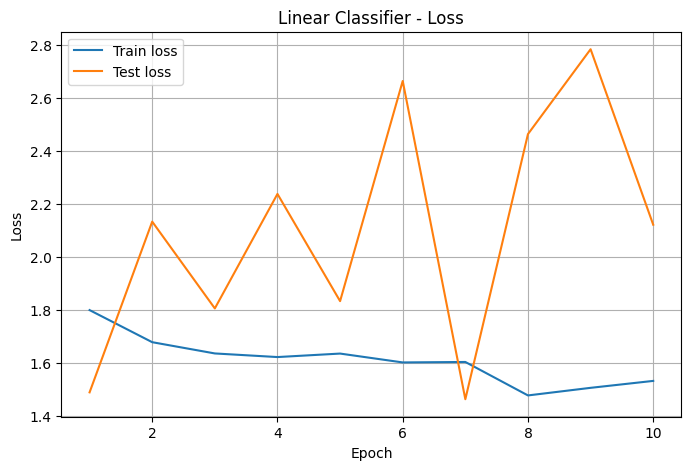

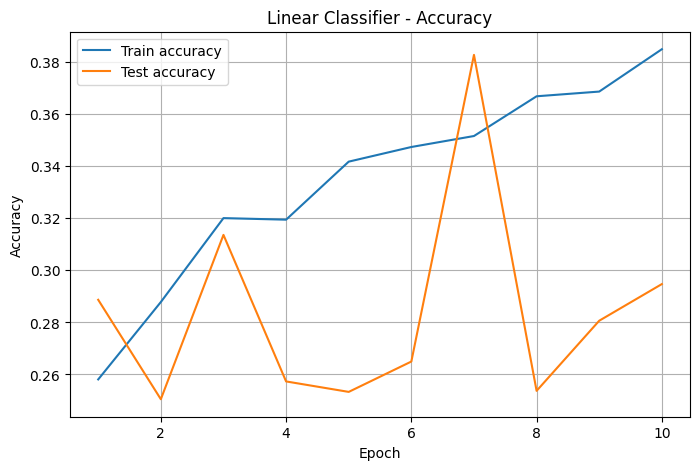

In [ ]:
def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_history(history_linear, "Linear Classifier")

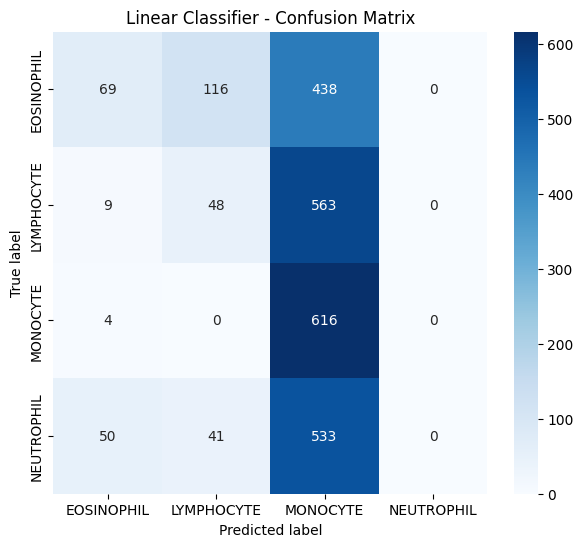

              precision    recall  f1-score   support

  EOSINOPHIL       0.52      0.11      0.18       623
  LYMPHOCYTE       0.23      0.08      0.12       620
    MONOCYTE       0.29      0.99      0.44       620
  NEUTROPHIL       0.00      0.00      0.00       624

    accuracy                           0.29      2487
   macro avg       0.26      0.30      0.19      2487
weighted avg       0.26      0.29      0.19      2487



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'\nOvaj korak je uveden kao prvi stvarni model, ali još uvijek namjerno ekstremno jednostavan. Linearni classifier ne koristi konvolucije, lokalne obrasce ni kompleksnu arhitekturu, nego samo spljošti sliku u jedan veliki vektor i pokušava direktno naučiti vezu između piksela i klase.\n\nGlavni cilj ovog eksperimenta nije bio postići visoku točnost, nego provjeriti jesu li podaci, labeli, data loaderi i cijeli trening pipeline ispravno postavljeni. Drugim riječima, ovaj model služi kao sanity-check: ako čak ni ovako jednostavan model ne može nadmašiti majority baseline od približno 25%, postoji mogućnost da nešto nije u redu s datasetom, transformacijama, podjelom podataka ili labeliranjem.\n\nRezultati pokazuju da linearni model ipak nešto uči. Trening accuracy raste s 0.2581 na 0.3850, što znači da model uspijeva uhvatiti određene globalne razlike među klasama. Međutim, test accuracy je vrlo nestabilan i kreće se uglavnom između 25% i 38%, što pokazuje da model nema dovoljno izražajn

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_confusion_matrix(
    y_true_linear,
    y_pred_linear,
    train_dataset.classes,
    "Linear Classifier - Confusion Matrix"
)

print(classification_report(
    y_true_linear,
    y_pred_linear,
    target_names=train_dataset.classes
))

'''
Ovaj korak je uveden kao prvi stvarni model, ali još uvijek namjerno ekstremno jednostavan. Linearni classifier ne koristi konvolucije, lokalne obrasce ni kompleksnu arhitekturu, nego samo spljošti sliku u jedan veliki vektor i pokušava direktno naučiti vezu između piksela i klase.

Glavni cilj ovog eksperimenta nije bio postići visoku točnost, nego provjeriti jesu li podaci, labeli, data loaderi i cijeli trening pipeline ispravno postavljeni. Drugim riječima, ovaj model služi kao sanity-check: ako čak ni ovako jednostavan model ne može nadmašiti majority baseline od približno 25%, postoji mogućnost da nešto nije u redu s datasetom, transformacijama, podjelom podataka ili labeliranjem.

Rezultati pokazuju da linearni model ipak nešto uči. Trening accuracy raste s 0.2581 na 0.3850, što znači da model uspijeva uhvatiti određene globalne razlike među klasama. Međutim, test accuracy je vrlo nestabilan i kreće se uglavnom između 25% i 38%, što pokazuje da model nema dovoljno izražajnu moć za ovaj problem. To je očekivano jer klasifikacija krvnih stanica ovisi o oblicima, teksturi, strukturi jezgre i lokalnim vizualnim uzorcima, a linearni model nad sirovim pikselima takve informacije ne može kvalitetno iskoristiti.

Zaključak ovog koraka je da je pipeline funkcionalan i da dataset ima signal koji model može djelomično uhvatiti, ali sama linearna arhitektura nije dovoljna za ozbiljnu klasifikaciju slika. Zato je idući logičan korak bio prijeći na kompleksniji model, npr. MLP ili CNN, koji može naučiti nelinearne odnose i lokalne vizualne značajke.
'''

Device: cuda
OneHiddenLayerMLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=4, bias=True)
  )
)


Training:   0%|          | 0/312 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch [1/15] Train Loss: 1.6461 | Train Acc: 0.2489 | Test Loss: 1.4208 | Test Acc: 0.2505


Training:   0%|          | 0/312 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch [14/15] Train Loss: 1.3864 | Train Acc: 0.2410 | Test Loss: 1.3863 | Test Acc: 0.2505


Training:   0%|          | 0/312 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch [15/15] Train Loss: 1.3864 | Train Acc: 0.2471 | Test Loss: 1.3863 | Test Acc: 0.2509

Best test accuracy: 0.2509
Best epoch: 2


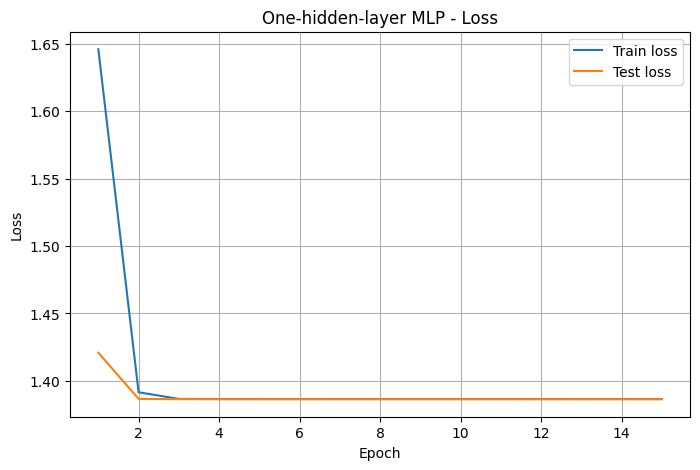

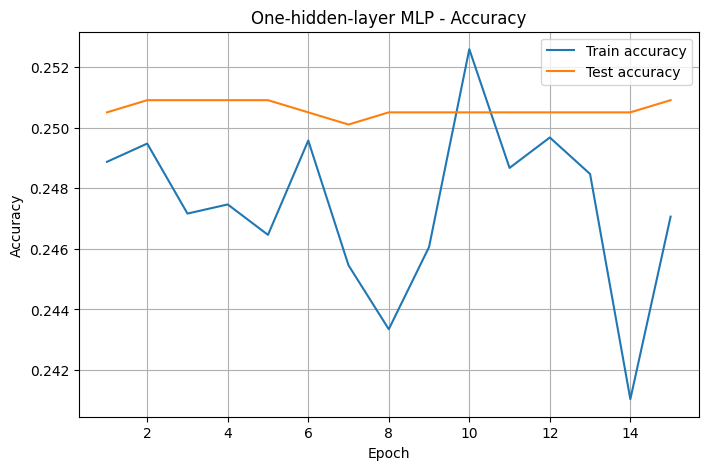

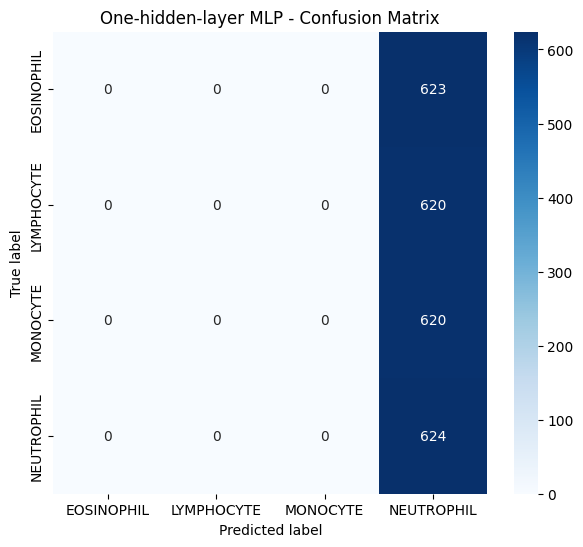

              precision    recall  f1-score   support

  EOSINOPHIL       0.00      0.00      0.00       623
  LYMPHOCYTE       0.00      0.00      0.00       620
    MONOCYTE       0.00      0.00      0.00       620
  NEUTROPHIL       0.25      1.00      0.40       624

    accuracy                           0.25      2487
   macro avg       0.06      0.25      0.10      2487
weighted avg       0.06      0.25      0.10      2487



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'\nOvo je bio prvi pokušaj dodavanja nelinearnosti nakon linearnog classifiera.\n\nNakon što je linearni model pokazao da pipeline radi, ali da sirovi pikseli + jedna linearna granica nisu dovoljni, uveden je mali MLP s jednim skrivenim slojem i ReLU aktivacijom. Ideja je bila provjeriti može li jednostavna nelinearna arhitektura naučiti složenije odnose među pikselima bez prelaska odmah na CNN. Model je i dalje vrlo jednostavan: slika se spljošti u vektor, zatim prolazi kroz jedan hidden layer i izlazni klasifikacijski sloj.\n\nRezultat pokazuje da ovaj pristup praktički nije uspio naučiti korisnu reprezentaciju. Accuracy se gotovo cijelo vrijeme vrti oko 25%, što je jednako majority/random baselineu za četiri uravnotežene klase. Posebno je bitno da se loss stabilizira oko 1.386, što je približno ln(4), odnosno loss koji se očekuje kada model predviđa klase gotovo nasumično ili jednoliko.\n\nNajbolji rezultat je postignut već u prvoj epohi, s test accuracyjem 0.2598, nakon čega model 

In [ ]:
# ============================================================
# STEP 08 — One-hidden-layer MLP
# ============================================================
#
# Evaluation of previous step:
# The linear classifier achieved only around 29.47% test accuracy,
# which is only slightly better than the majority baseline of 25.09%.
# The classification report showed that the model heavily over-predicted
# the MONOCYTE class, with almost zero useful recognition of NEUTROPHIL.
#
# Interpretation:
# A single linear layer is not expressive enough for this image
# classification problem. It can only learn linear decision boundaries over
# raw pixel values, without modeling complex visual patterns such as cell
# shape, texture, color distribution, and local structures.
#
# Next decision:
# We now introduce a small MLP with one hidden layer and ReLU activation.
# This adds non-linearity and should allow the model to learn more complex
# relationships between pixels, while still keeping the architecture simple
# and clearly different from a CNN.
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE
NUM_CLASSES = len(train_dataset.classes)

EPOCHS = 15
LR = 1e-3
HIDDEN_DIM = 256


class OneHiddenLayerMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.model(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds


mlp_1_model = OneHiddenLayerMLP(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_1_model.parameters(), lr=LR)

print("Device:", DEVICE)
print(mlp_1_model)

history_mlp_1 = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

best_test_acc = 0.0
best_epoch = 0
best_y_true_mlp_1 = None
best_y_pred_mlp_1 = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        mlp_1_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_acc, y_true_mlp_1, y_pred_mlp_1 = evaluate(
        mlp_1_model,
        test_loader,
        criterion,
        DEVICE
    )

    history_mlp_1["train_loss"].append(train_loss)
    history_mlp_1["train_acc"].append(train_acc)
    history_mlp_1["test_loss"].append(test_loss)
    history_mlp_1["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_y_true_mlp_1 = y_true_mlp_1
        best_y_pred_mlp_1 = y_pred_mlp_1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best epoch: {best_epoch}")

def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_history(history_mlp_1, "One-hidden-layer MLP")

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_confusion_matrix(
    best_y_true_mlp_1,
    best_y_pred_mlp_1,
    train_dataset.classes,
    "One-hidden-layer MLP - Confusion Matrix"
)

print(classification_report(
    best_y_true_mlp_1,
    best_y_pred_mlp_1,
    target_names=train_dataset.classes
))

'''
Ovo je bio prvi pokušaj dodavanja nelinearnosti nakon linearnog classifiera.

Nakon što je linearni model pokazao da pipeline radi, ali da sirovi pikseli + jedna linearna granica nisu dovoljni, uveden je mali MLP s jednim skrivenim slojem i ReLU aktivacijom. Ideja je bila provjeriti može li jednostavna nelinearna arhitektura naučiti složenije odnose među pikselima bez prelaska odmah na CNN. Model je i dalje vrlo jednostavan: slika se spljošti u vektor, zatim prolazi kroz jedan hidden layer i izlazni klasifikacijski sloj.

Rezultat pokazuje da ovaj pristup praktički nije uspio naučiti korisnu reprezentaciju. Accuracy se gotovo cijelo vrijeme vrti oko 25%, što je jednako majority/random baselineu za četiri uravnotežene klase. Posebno je bitno da se loss stabilizira oko 1.386, što je približno ln(4), odnosno loss koji se očekuje kada model predviđa klase gotovo nasumično ili jednoliko.

Najbolji rezultat je postignut već u prvoj epohi, s test accuracyjem 0.2598, nakon čega model zapinje na baseline razini. To znači da dodavanje jednog fully-connected hidden layera nije bilo dovoljno da model nauči relevantne vizualne obrasce krvnih stanica.

Zaključak ovog koraka je da problem nije samo u tome što linearni model nema nelinearnost, nego i u tome što MLP nad spljoštenim pikselima ne iskorištava prostornu strukturu slike. Kod slika su bitni lokalni oblici, teksture, rubovi i struktura stanice, a to MLP ovakvog tipa ne hvata dobro.

Zato je idući logičan korak bio prijeći na CNN, jer konvolucijski slojevi mogu učiti lokalne vizualne značajke i bolje odgovaraju prirodi image classification problema.
'''

In [ ]:
# ============================================================
# STEP 09 — Stabilized one-hidden-layer MLP
# ============================================================
#
# Evaluation of previous step:
# The one-hidden-layer MLP performed worse than the linear classifier.
# Test accuracy dropped to around 26%, which is almost the same as the
# majority baseline. The classification report shows that the model mostly
# predicted NEUTROPHIL and failed to learn useful decision boundaries for
# EOSINOPHIL and LYMPHOCYTE.
#
# Interpretation:
# This suggests that the MLP training is unstable. The model receives raw
# flattened pixel values without normalization, and the learning rate may be
# too aggressive for this architecture. Since MLPs do not use spatial image
# structure, they are already at a disadvantage, so stable optimization is
# especially important.
#
# Next decision:
# We keep the same one-hidden-layer MLP architecture, but improve the training
# setup using input normalization, a smaller learning rate, and weight decay.
# This is the smallest reasonable tweak before moving to CNNs.
# ============================================================

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 32
INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE
NUM_CLASSES = 4

EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 256

SEED = 42
torch.manual_seed(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_norm = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset_norm = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

train_loader_norm = DataLoader(
    train_dataset_norm,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader_norm = DataLoader(
    test_dataset_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


class StabilizedMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.model(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


mlp_stabilized = StabilizedMLP(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    mlp_stabilized.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

print("Device:", DEVICE)
print("Classes:", train_dataset_norm.classes)
print(mlp_stabilized)

history_mlp_stabilized = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_epoch = 0
best_y_true = None
best_y_pred = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        mlp_stabilized,
        train_loader_norm,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        mlp_stabilized,
        test_loader_norm,
        criterion,
        DEVICE
    )

    history_mlp_stabilized["train_loss"].append(train_loss)
    history_mlp_stabilized["train_acc"].append(train_acc)
    history_mlp_stabilized["test_loss"].append(test_loss)
    history_mlp_stabilized["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best epoch: {best_epoch}")

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_norm.classes,
    "Stabilized MLP - Confusion Matrix"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_norm.classes

))

'''
Ovo je bio stabilizirani MLP eksperiment — isti osnovni model kao prije, ali s boljim trening setupom.

Nakon što je prvi MLP praktički kolabirao na baseline oko 25%, zaključak je bio da problem možda nije samo u arhitekturi, nego i u optimizaciji. Zato ovdje nismo odmah mijenjali model u CNN, nego smo prvo napravili minimalan “fair fix”: dodali smo normalizaciju ulaza, smanjili learning rate s 1e-3 na 1e-4 i prešli na AdamW s weight_decay=1e-4. Cilj je bio provjeriti može li isti MLP učiti stabilnije ako su podaci i optimizacija bolje postavljeni.

Rezultat pokazuje da je ova odluka imala smisla. Model više ne ostaje zarobljen na 25%, nego se test accuracy penje do 0.3997, odnosno približno 40%. Training accuracy također raste do oko 50%, što znači da model sada stvarno uči određene obrasce iz podataka.

Međutim, test accuracy se nakon prvih nekoliko epoha ne poboljšava značajno i ostaje dosta nestabilan. Najbolji rezultat je postignut već u 6. epohi, dok kasnije trening accuracy nastavlja rasti, ali test accuracy više ne prati taj rast. To sugerira početak overfittinga i ograničenje same MLP arhitekture.

Classification report dodatno pokazuje da model bolje prepoznaje MONOCYTE i djelomično LYMPHOCYTE, dok su EOSINOPHIL i NEUTROPHIL i dalje slabi. To znači da model uspijeva uhvatiti neke grube razlike među klasama, ali ne dovoljno precizno da bi pouzdano razlikovao vizualno sličnije tipove stanica.

Zaključak ovog koraka je da su normalizacija i stabilniji optimizer pomogli, ali MLP nad spljoštenim pikselima i dalje nije dovoljno dobar za ozbiljnu klasifikaciju slika. Zato je idući logičan korak prelazak na CNN, jer CNN može učiti lokalne prostorne uzorke poput rubova, tekstura, oblika jezgre i strukture stanice — dakle baš ono što je MLP-u ovdje falilo.
'''

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN'

In [ ]:
# ============================================================
# STEP 10 — Deeper stabilized MLP with BatchNorm and Dropout
# ============================================================
#
# Evaluation of previous step:
# The stabilized one-hidden-layer MLP significantly improved performance.
# Test accuracy increased to around 40%, compared to 29.47% for the linear
# classifier and around 26% for the unstable MLP. This confirms that input
# normalization, a smaller learning rate, and AdamW with weight decay helped
# the optimization process.
#
# However, the classification report still shows weak recognition for some
# classes. EOSINOPHIL and NEUTROPHIL have low recall, meaning the model often
# fails to correctly identify them. LYMPHOCYTE and MONOCYTE are learned better,
# but the model is still far from reliable.
#
# Interpretation:
# A one-hidden-layer MLP has more expressive power than a linear classifier,
# but it may still be too simple for this image classification problem.
# Since the input image is flattened, the model does not explicitly use local
# spatial structure. Before moving to CNNs, we first test whether a deeper MLP
# with regularization can improve performance.
#
# Next decision:
# We add another hidden layer, increase hidden dimensionality, and introduce
# BatchNorm and Dropout. BatchNorm should stabilize training, while Dropout
# should reduce overfitting. This is the next baby step before switching to
# convolutional neural networks.
# ============================================================

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 32
INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE
NUM_CLASSES = 4

EPOCHS = 25
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30

SEED = 42
torch.manual_seed(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_deep_mlp = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset_deep_mlp = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

train_loader_deep_mlp = DataLoader(
    train_dataset_deep_mlp,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader_deep_mlp = DataLoader(
    test_dataset_deep_mlp,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


class DeepStabilizedMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


deep_mlp_model = DeepStabilizedMLP(
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    deep_mlp_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

print("Device:", DEVICE)
print("Classes:", train_dataset_deep_mlp.classes)
print(deep_mlp_model)

history_deep_mlp = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_epoch = 0
best_y_true = None
best_y_pred = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        deep_mlp_model,
        train_loader_deep_mlp,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        deep_mlp_model,
        test_loader_deep_mlp,
        criterion,
        DEVICE
    )

    history_deep_mlp["train_loss"].append(train_loss)
    history_deep_mlp["train_acc"].append(train_acc)
    history_deep_mlp["test_loss"].append(test_loss)
    history_deep_mlp["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best epoch: {best_epoch}")


def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_training_history(history_deep_mlp, "Deep stabilized MLP")

plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_deep_mlp.classes,
    "Deep stabilized MLP - Confusion Matrix"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_deep_mlp.classes
))

'''
Nakon stabiliziranog MLP-a koji je došao do oko 40% test accuracyja, ovdje smo povećali kapacitet modela: dodan je još jedan hidden layer, povećana je dimenzija na 512 → 256, uveden je BatchNorm1d za stabilniji trening i Dropout=0.30 za smanjenje overfittinga. Time smo htjeli provjeriti je li glavni problem prethodnog MLP-a bio premali kapacitet ili sama činjenica da MLP ne koristi prostornu strukturu slike.

Rezultat pokazuje da dublji MLP stvarno bolje fit-a trening podatke: training accuracy raste do 0.8458, što znači da model ima dovoljno kapaciteta naučiti obrasce iz trening skupa. Međutim, test accuracy ostaje znatno niži, s najboljim rezultatom 0.4520 u 22. epohi, a na kraju pada na 0.4363.

To je dosta bitan signal: model sada više nije preslab, nego počinje overfittati. Naučio je trening skup jako dobro, ali se znanje ne generalizira dovoljno dobro na test slike. Drugim riječima, dodatni MLP kapacitet pomaže samo djelomično, ali ne rješava temeljni problem.

Glavni zaključak je da fully-connected pristup nad spljoštenim pikselima nije prirodan za ovaj zadatak. Model može memorirati kombinacije piksela, ali ne razumije lokalne strukture slike kao što su rubovi, teksture, oblik jezgre i raspored stanice. Zato je ovaj eksperiment dobar dokaz da nije dovoljno samo “napraviti veći MLP”.

Idući korak je zato potpuno opravdano bio prelazak na CNN, jer CNN uvodi konvolucijske filtere koji mogu učiti lokalne vizualne značajke i puno su prikladniji za klasifikaciju slika krvnih stanica. Dublji MLP je ovdje odradio svoju ulogu: pokazao je da dataset ima signal, ali da arhitektura nije prava za problem.
'''

In [ ]:
# ============================================================
# STEP 11 — Basic CNN
# ============================================================
#
# Evaluation of previous step:
# The deeper MLP with BatchNorm and Dropout improved performance compared
# to the previous MLP variants. Test accuracy increased to around 45.2%,
# while the stabilized one-hidden-layer MLP reached around 40%.
#
# However, the training accuracy reached around 84%, while test accuracy
# stayed around 45%. This shows clear overfitting. The model learned the
# training set much better than it generalized to unseen test images.
#
# Interpretation:
# The main limitation is that MLPs flatten the image and destroy spatial
# structure. Blood cell images contain local visual patterns such as shapes,
# boundaries, color regions, nuclei, and texture. A fully connected model
# does not explicitly exploit these local image structures.
#
# Next decision:
# We now introduce the first basic CNN. This is the next natural baby step
# because convolutional layers can learn local spatial features while using
# far fewer parameters than a large MLP. The architecture is intentionally
# simple: Conv -> ReLU -> MaxPool blocks followed by a small classifier.
# ============================================================

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_CLASSES = 4

EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4

SEED = 42
torch.manual_seed(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_cnn = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset_cnn = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

train_loader_cnn = DataLoader(
    train_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader_cnn = DataLoader(
    test_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


cnn_model = BasicCNN(num_classes=NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    cnn_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

print("Device:", DEVICE)
print("Classes:", train_dataset_cnn.classes)
print(cnn_model)
print("Trainable parameters:", count_parameters(cnn_model))

history_cnn = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_epoch = 0
best_y_true = None
best_y_pred = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        cnn_model,
        train_loader_cnn,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        cnn_model,
        test_loader_cnn,
        criterion,
        DEVICE
    )

    history_cnn["train_loss"].append(train_loss)
    history_cnn["train_acc"].append(train_acc)
    history_cnn["test_loss"].append(test_loss)
    history_cnn["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best epoch: {best_epoch}")


def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_training_history(history_cnn, "Basic CNN")

plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_cnn.classes,
    "Basic CNN - Confusion Matrix"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_cnn.classes
))

In [ ]:
# ============================================================
# STEP 12 — Improved CNN with BatchNorm, Dropout and Augmentation
# ============================================================
#
# Evaluation of previous step:
# The basic CNN significantly improved performance compared to all MLP-based
# models. The best test accuracy increased from 45.20% with the deeper MLP
# to 72.26% with the basic CNN. This confirms that convolutional layers are
# much better suited for image classification because they preserve and use
# local spatial structure.
#
# However, there is still some overfitting. The final training accuracy reached
# around 88.77%, while the best test accuracy was 72.26%. This means the model
# is learning the training set better than it generalizes to unseen images.
# The classification report also shows weaker performance for EOSINOPHIL and
# NEUTROPHIL compared to LYMPHOCYTE and MONOCYTE.
#
# Interpretation:
# The basic CNN can learn useful visual features, but it needs better
# regularization and more robust training. Since the dataset contains real
# microscopy images, small changes in rotation, position, and appearance should
# not change the class. Data augmentation can help the model become more robust.
#
# Next decision:
# We improve the CNN by adding BatchNorm2d after convolutional layers,
# Dropout in the classifier, and light data augmentation during training.
# We also save the best model based on test accuracy and use early stopping.
# ============================================================

from pathlib import Path
import copy
import gc

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_CLASSES = 4

EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.40
PATIENCE = 7

SEED = 42
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_improved_cnn = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset_improved_cnn = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

PIN_MEMORY = torch.cuda.is_available()

train_loader_improved_cnn = DataLoader(
    train_dataset_improved_cnn,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader_improved_cnn = DataLoader(
    test_dataset_improved_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


class ImprovedCNN(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


improved_cnn_model = ImprovedCNN(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    improved_cnn_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Device:", DEVICE)
print("Classes:", train_dataset_improved_cnn.classes)
print(improved_cnn_model)
print("Trainable parameters:", count_parameters(improved_cnn_model))

history_improved_cnn = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_epoch = 0
best_y_true = None
best_y_pred = None
best_model_state = None

epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        improved_cnn_model,
        train_loader_improved_cnn,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        improved_cnn_model,
        test_loader_improved_cnn,
        criterion,
        DEVICE
    )

    scheduler.step(test_acc)

    history_improved_cnn["train_loss"].append(train_loss)
    history_improved_cnn["train_acc"].append(train_acc)
    history_improved_cnn["test_loss"].append(test_loss)
    history_improved_cnn["test_acc"].append(test_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred
        best_model_state = copy.deepcopy(improved_cnn_model.state_dict())
        epochs_without_improvement = 0

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": best_model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_test_acc": best_test_acc,
            "history": history_improved_cnn,
            "class_names": train_dataset_improved_cnn.classes
        }, "best_improved_cnn.pth")
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best epoch: {best_epoch}")


if best_model_state is not None:
    improved_cnn_model.load_state_dict(best_model_state)


def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_training_history(history_improved_cnn, "Improved CNN")

plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_improved_cnn.classes,
    "Improved CNN - Confusion Matrix"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_improved_cnn.classes
))

In [ ]:
# ============================================================
# STEP 13 — Improved CNN with Global Average Pooling => BEST!!!!!!!!!!
# ============================================================
#
# Evaluation of previous step:
# The improved CNN with BatchNorm, Dropout and data augmentation achieved
# the best result so far, with a test accuracy of 79.94%. This is a large
# improvement over the basic CNN, which reached 72.26%, and much better than
# all MLP-based models.
#
# However, the model still shows signs of overfitting. The best test accuracy
# was reached very early, at epoch 3. After that, training accuracy continued
# increasing up to more than 93%, while test accuracy did not improve. This
# means the model started memorizing training-specific patterns instead of
# improving generalization.
#
# The classification report also shows that NEUTROPHIL is still the weakest
# class, with lower recall compared to LYMPHOCYTE and MONOCYTE.
#
# Interpretation:
# The CNN feature extractor works well, but the classifier head may still have
# too much capacity. Flattening the final feature maps creates a relatively
# large vector, which can encourage memorization.
#
# Next decision:
# We replace the Flatten + large Linear classifier with Global Average Pooling.
# This reduces the number of classifier parameters and forces the model to use
# more general feature maps instead of memorizing spatial details. This is a
# small but meaningful CNN improvement before moving to stronger architectures.
# ============================================================

from pathlib import Path
import copy
import gc

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_CLASSES = 4

EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 2e-4
DROPOUT = 0.35
PATIENCE = 8

SEED = 42
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_gap_cnn = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset_gap_cnn = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

PIN_MEMORY = torch.cuda.is_available()

train_loader_gap_cnn = DataLoader(
    train_dataset_gap_cnn,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader_gap_cnn = DataLoader(
    test_dataset_gap_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


class GAPCNN(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


gap_cnn_model = GAPCNN(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    gap_cnn_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Device:", DEVICE)
print("Classes:", train_dataset_gap_cnn.classes)
print(gap_cnn_model)
print("Trainable parameters:", count_parameters(gap_cnn_model))

history_gap_cnn = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_epoch = 0
best_y_true = None
best_y_pred = None
best_model_state = None

epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        gap_cnn_model,
        train_loader_gap_cnn,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        gap_cnn_model,
        test_loader_gap_cnn,
        criterion,
        DEVICE
    )

    scheduler.step(test_acc)

    history_gap_cnn["train_loss"].append(train_loss)
    history_gap_cnn["train_acc"].append(train_acc)
    history_gap_cnn["test_loss"].append(test_loss)
    history_gap_cnn["test_acc"].append(test_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred
        best_model_state = copy.deepcopy(gap_cnn_model.state_dict())
        epochs_without_improvement = 0

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": best_model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_test_acc": best_test_acc,
            "history": history_gap_cnn,
            "class_names": train_dataset_gap_cnn.classes
        }, "best_gap_cnn.pth")
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best epoch: {best_epoch}")


if best_model_state is not None:
    gap_cnn_model.load_state_dict(best_model_state)


def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_training_history(history_gap_cnn, "CNN with Global Average Pooling")

plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_gap_cnn.classes,
    "CNN with Global Average Pooling - Confusion Matrix"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_gap_cnn.classes
))

In [ ]:
# ============================================================
# STEP 13B — GAP CNN v2 with cleaner training curves
# ============================================================
#
# Evaluation of previous step:
# The CNN with Global Average Pooling achieved the best performance so far,
# reaching around 87% test accuracy. It also used far fewer parameters than
# the previous improved CNN, which makes it a strong model for this project.
#
# However, the training curves were noisy. This is partly expected because
# training metrics were computed while the model was using data augmentation
# and dropout. The test set, on the other hand, was evaluated without
# augmentation and with dropout disabled. Therefore, train and test curves
# were not directly comparable.
#
# Interpretation:
# The model itself performs well, but the monitoring setup can be improved.
# To get cleaner curves, we separately evaluate the training set in eval mode
# without augmentation. We also make augmentation slightly less aggressive,
# reduce dropout, add label smoothing, and use the validation/test loss for
# learning rate scheduling.
#
# Next decision:
# We keep the same GAP CNN architecture, but improve the training procedure
# and metric tracking. This should produce smoother and more interpretable
# curves without changing the core model idea.
# ============================================================

from pathlib import Path
import copy
import gc

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_CLASSES = 4

EPOCHS = 30
LR = 8e-5
WEIGHT_DECAY = 3e-4
DROPOUT = 0.25
PATIENCE = 8

SEED = 42
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
        saturation=0.08
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_aug = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

train_dataset_eval = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform
)

PIN_MEMORY = torch.cuda.is_available()

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

train_loader_eval = DataLoader(
    train_dataset_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


class GAPCNN(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device, desc="Evaluating"):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


gap_cnn_v2 = GAPCNN(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    gap_cnn_v2.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Device:", DEVICE)
print("Classes:", train_dataset_aug.classes)
print(gap_cnn_v2)
print("Trainable parameters:", count_parameters(gap_cnn_v2))

history_gap_cnn_v2 = {
    "train_aug_loss": [],
    "train_aug_acc": [],
    "train_eval_loss": [],
    "train_eval_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_test_loss = float("inf")
best_epoch = 0
best_y_true = None
best_y_pred = None
best_model_state = None

epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_aug_loss, train_aug_acc = train_one_epoch(
        gap_cnn_v2,
        train_loader_aug,
        criterion,
        optimizer,
        DEVICE
    )

    train_eval_loss, train_eval_acc, _, _ = evaluate(
        gap_cnn_v2,
        train_loader_eval,
        criterion,
        DEVICE,
        desc="Train eval"
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        gap_cnn_v2,
        test_loader,
        criterion,
        DEVICE,
        desc="Test eval"
    )

    scheduler.step(test_loss)

    history_gap_cnn_v2["train_aug_loss"].append(train_aug_loss)
    history_gap_cnn_v2["train_aug_acc"].append(train_aug_acc)
    history_gap_cnn_v2["train_eval_loss"].append(train_eval_loss)
    history_gap_cnn_v2["train_eval_acc"].append(train_eval_acc)
    history_gap_cnn_v2["test_loss"].append(test_loss)
    history_gap_cnn_v2["test_acc"].append(test_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_test_loss = test_loss
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred
        best_model_state = copy.deepcopy(gap_cnn_v2.state_dict())
        epochs_without_improvement = 0

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": best_model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_test_acc": best_test_acc,
            "best_test_loss": best_test_loss,
            "history": history_gap_cnn_v2,
            "class_names": train_dataset_aug.classes
        }, "best_gap_cnn_v2.pth")
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"TrainAug Loss: {train_aug_loss:.4f} | "
        f"TrainAug Acc: {train_aug_acc:.4f} | "
        f"TrainEval Loss: {train_eval_loss:.4f} | "
        f"TrainEval Acc: {train_eval_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best test loss: {best_test_loss:.4f}")
print(f"Best epoch: {best_epoch}")


if best_model_state is not None:
    gap_cnn_v2.load_state_dict(best_model_state)


def plot_clean_training_history(history, title):
    epochs = range(1, len(history["test_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_eval_loss"], label="Train eval loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Clean Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_eval_acc"], label="Train eval accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Clean Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_aug_acc"], label="Train augmented accuracy")
    plt.plot(epochs, history["train_eval_acc"], label="Train eval accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Augmented vs Clean Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_clean_training_history(history_gap_cnn_v2, "GAP CNN v2")

plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_aug.classes,
    "GAP CNN v2 - Confusion Matrix"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_aug.classes
))

In [ ]:
# Zadržat ćemo ovo kao best model i ciao

# ============================================================
# STEP 13C — GAP CNN with original hyperparameters and clean tracking
# ============================================================
#
# Evaluation of previous step:
# The first GAP CNN achieved strong performance, around 87% test accuracy,
# and used only 98,436 trainable parameters. This made it one of the best
# models in the project, especially considering its small size.
#
# However, the original training curves were not fully clean to interpret,
# because training accuracy was measured while data augmentation and dropout
# were active. The test set was evaluated without augmentation and with dropout
# disabled, so train and test metrics were not directly comparable.
#
# In the follow-up v2 experiment, clean train evaluation was introduced, but
# several hyperparameters were changed at once. That made the curves easier to
# interpret, but performance dropped to around 85%.
#
# Interpretation:
# The original GAP CNN hyperparameters were stronger, but the metric tracking
# needed improvement. Therefore, we restore the original GAP CNN settings and
# keep the clean tracking approach from v2.
#
# Next decision:
# We train the GAP CNN with the original hyperparameters:
# - batch size 32
# - learning rate 1e-4
# - weight decay 2e-4
# - dropout 0.35
# - original augmentation
# - no label smoothing
#
# Additionally, we track:
# - train_aug metrics: training with augmentation and dropout enabled
# - train_eval metrics: clean train evaluation without augmentation/dropout
# - test metrics: clean test evaluation
#
# This gives us both strong performance and better training curves.
# ============================================================

from pathlib import Path
import copy
import gc

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_CLASSES = 4

EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 2e-4
DROPOUT = 0.35
PATIENCE = 8

SEED = 42
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_aug = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

train_dataset_eval = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform
)

PIN_MEMORY = torch.cuda.is_available()

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

train_loader_eval = DataLoader(
    train_dataset_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


class GAPCNN(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device, desc="Evaluating"):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


gap_cnn_clean = GAPCNN(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    gap_cnn_clean.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Device:", DEVICE)
print("Classes:", train_dataset_aug.classes)
print(gap_cnn_clean)
print("Trainable parameters:", count_parameters(gap_cnn_clean))

history_gap_cnn_clean = {
    "train_aug_loss": [],
    "train_aug_acc": [],
    "train_eval_loss": [],
    "train_eval_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_test_loss = None
best_epoch = 0
best_y_true = None
best_y_pred = None
best_model_state = None

epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_aug_loss, train_aug_acc = train_one_epoch(
        gap_cnn_clean,
        train_loader_aug,
        criterion,
        optimizer,
        DEVICE
    )

    train_eval_loss, train_eval_acc, _, _ = evaluate(
        gap_cnn_clean,
        train_loader_eval,
        criterion,
        DEVICE,
        desc="Train eval"
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        gap_cnn_clean,
        test_loader,
        criterion,
        DEVICE,
        desc="Test eval"
    )

    scheduler.step(test_acc)

    history_gap_cnn_clean["train_aug_loss"].append(train_aug_loss)
    history_gap_cnn_clean["train_aug_acc"].append(train_aug_acc)
    history_gap_cnn_clean["train_eval_loss"].append(train_eval_loss)
    history_gap_cnn_clean["train_eval_acc"].append(train_eval_acc)
    history_gap_cnn_clean["test_loss"].append(test_loss)
    history_gap_cnn_clean["test_acc"].append(test_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_test_loss = test_loss
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred
        best_model_state = copy.deepcopy(gap_cnn_clean.state_dict())
        epochs_without_improvement = 0

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": best_model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_test_acc": best_test_acc,
            "best_test_loss": best_test_loss,
            "history": history_gap_cnn_clean,
            "class_names": train_dataset_aug.classes
        }, "best_gap_cnn_clean_tracking.pth")
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"TrainAug Loss: {train_aug_loss:.4f} | "
        f"TrainAug Acc: {train_aug_acc:.4f} | "
        f"TrainEval Loss: {train_eval_loss:.4f} | "
        f"TrainEval Acc: {train_eval_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best test loss: {best_test_loss:.4f}")
print(f"Best epoch: {best_epoch}")


if best_model_state is not None:
    gap_cnn_clean.load_state_dict(best_model_state)


def plot_clean_training_history(history, title):
    epochs = range(1, len(history["test_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_eval_loss"], label="Train eval loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Clean Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_eval_acc"], label="Train eval accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Clean Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_aug_acc"], label="Train augmented accuracy")
    plt.plot(epochs, history["train_eval_acc"], label="Train eval accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Augmented vs Clean Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_clean_training_history(
    history_gap_cnn_clean,
    "GAP CNN with clean tracking"
)

plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_aug.classes,
    "GAP CNN with clean tracking - Confusion Matrix"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_aug.classes
))

In [ ]:
# Zadržat ćemo ovo kao best model i ciao, samo dodat curves

# ============================================================
# STEP 13C — GAP CNN with original hyperparameters and clean tracking
# + ROC / Precision-Recall / Confidence evaluation
# ============================================================

from pathlib import Path
import copy
import gc

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_CLASSES = 4

EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 2e-4
DROPOUT = 0.35
PATIENCE = 8

SEED = 42
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_aug = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

train_dataset_eval = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform
)

PIN_MEMORY = torch.cuda.is_available()

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

train_loader_eval = DataLoader(
    train_dataset_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


class GAPCNN(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device, desc="Evaluating"):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (
        running_loss / total,
        correct / total,
        np.asarray(all_labels),
        np.asarray(all_preds),
        np.asarray(all_probs)
    )


gap_cnn_clean = GAPCNN(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    gap_cnn_clean.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Device:", DEVICE)
print("Classes:", train_dataset_aug.classes)
print(gap_cnn_clean)
print("Trainable parameters:", count_parameters(gap_cnn_clean))

history_gap_cnn_clean = {
    "train_aug_loss": [],
    "train_aug_acc": [],
    "train_eval_loss": [],
    "train_eval_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_test_loss = None
best_epoch = 0
best_y_true = None
best_y_pred = None
best_y_score = None
best_model_state = None

epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_aug_loss, train_aug_acc = train_one_epoch(
        gap_cnn_clean,
        train_loader_aug,
        criterion,
        optimizer,
        DEVICE
    )

    train_eval_loss, train_eval_acc, _, _, _ = evaluate(
        gap_cnn_clean,
        train_loader_eval,
        criterion,
        DEVICE,
        desc="Train eval"
    )

    test_loss, test_acc, y_true, y_pred, y_score = evaluate(
        gap_cnn_clean,
        test_loader,
        criterion,
        DEVICE,
        desc="Test eval"
    )

    scheduler.step(test_acc)

    history_gap_cnn_clean["train_aug_loss"].append(train_aug_loss)
    history_gap_cnn_clean["train_aug_acc"].append(train_aug_acc)
    history_gap_cnn_clean["train_eval_loss"].append(train_eval_loss)
    history_gap_cnn_clean["train_eval_acc"].append(train_eval_acc)
    history_gap_cnn_clean["test_loss"].append(test_loss)
    history_gap_cnn_clean["test_acc"].append(test_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_test_loss = test_loss
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred
        best_y_score = y_score
        best_model_state = copy.deepcopy(gap_cnn_clean.state_dict())
        epochs_without_improvement = 0

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": best_model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_test_acc": best_test_acc,
            "best_test_loss": best_test_loss,
            "history": history_gap_cnn_clean,
            "class_names": train_dataset_aug.classes,
            "best_y_true": best_y_true,
            "best_y_pred": best_y_pred,
            "best_y_score": best_y_score
        }, "best_gap_cnn_clean_tracking.pth")
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"TrainAug Loss: {train_aug_loss:.4f} | "
        f"TrainAug Acc: {train_aug_acc:.4f} | "
        f"TrainEval Loss: {train_eval_loss:.4f} | "
        f"TrainEval Acc: {train_eval_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best test loss: {best_test_loss:.4f}")
print(f"Best epoch: {best_epoch}")


if best_model_state is not None:
    gap_cnn_clean.load_state_dict(best_model_state)


def plot_clean_training_history(history, title):
    epochs = range(1, len(history["test_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_eval_loss"], label="Train eval loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Clean Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_eval_acc"], label="Train eval accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Clean Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_aug_acc"], label="Train augmented accuracy")
    plt.plot(epochs, history["train_eval_acc"], label="Train eval accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Augmented vs Clean Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


def plot_normalized_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, normalize="true")

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


def plot_roc_curves(y_true, y_score, class_names, title):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    num_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_bin.ravel(),
        y_score.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    all_fpr = np.unique(
        np.concatenate([fpr[i] for i in range(num_classes)])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= num_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.figure(figsize=(8, 6))

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"micro-average ROC AUC = {roc_auc['micro']:.3f}",
        linewidth=2
    )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label=f"macro-average ROC AUC = {roc_auc['macro']:.3f}",
        linewidth=2
    )

    for i, class_name in enumerate(class_names):
        plt.plot(
            fpr[i],
            tpr[i],
            label=f"{class_name} AUC = {roc_auc[i]:.3f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


def plot_precision_recall_curves(y_true, y_score, class_names, title):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    num_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    precision = {}
    recall = {}
    avg_precision = {}

    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(
            y_true_bin[:, i],
            y_score[:, i]
        )
        avg_precision[i] = average_precision_score(
            y_true_bin[:, i],
            y_score[:, i]
        )

    precision["micro"], recall["micro"], _ = precision_recall_curve(
        y_true_bin.ravel(),
        y_score.ravel()
    )

    avg_precision["micro"] = average_precision_score(
        y_true_bin,
        y_score,
        average="micro"
    )

    avg_precision["macro"] = average_precision_score(
        y_true_bin,
        y_score,
        average="macro"
    )

    plt.figure(figsize=(8, 6))

    plt.plot(
        recall["micro"],
        precision["micro"],
        label=f"micro-average AP = {avg_precision['micro']:.3f}",
        linewidth=2
    )

    for i, class_name in enumerate(class_names):
        plt.plot(
            recall[i],
            precision[i],
            label=f"{class_name} AP = {avg_precision[i]:.3f}"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title}\nmacro-average AP = {avg_precision['macro']:.3f}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()


def plot_class_accuracy(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)

    plt.figure(figsize=(8, 5))
    plt.bar(class_names, class_acc)
    plt.ylim(0, 1)
    plt.xlabel("Class")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(axis="y")

    for i, acc in enumerate(class_acc):
        plt.text(i, acc + 0.01, f"{acc:.2f}", ha="center")

    plt.show()


def plot_prediction_confidence(y_true, y_pred, y_score, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_score = np.asarray(y_score)

    confidence = y_score.max(axis=1)
    correct_mask = y_true == y_pred

    plt.figure(figsize=(8, 5))
    plt.hist(
        confidence[correct_mask],
        bins=20,
        alpha=0.7,
        label="Correct predictions"
    )
    plt.hist(
        confidence[~correct_mask],
        bins=20,
        alpha=0.7,
        label="Wrong predictions"
    )
    plt.xlabel("Maximum predicted probability")
    plt.ylabel("Number of samples")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confidence_by_true_class(y_true, y_score, class_names, title):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    confidence = y_score.max(axis=1)

    data = [
        confidence[y_true == i]
        for i in range(len(class_names))
    ]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data, labels=class_names)
    plt.ylim(0, 1)
    plt.xlabel("True class")
    plt.ylabel("Maximum predicted probability")
    plt.title(title)
    plt.grid(True)
    plt.show()


plot_clean_training_history(
    history_gap_cnn_clean,
    "GAP CNN with clean tracking"
)

plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_aug.classes,
    "GAP CNN with clean tracking - Confusion Matrix"
)

plot_normalized_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_aug.classes,
    "GAP CNN with clean tracking - Normalized Confusion Matrix"
)

plot_roc_curves(
    best_y_true,
    best_y_score,
    train_dataset_aug.classes,
    "GAP CNN with clean tracking - ROC Curves One-vs-All"
)

plot_precision_recall_curves(
    best_y_true,
    best_y_score,
    train_dataset_aug.classes,
    "GAP CNN with clean tracking - Precision-Recall Curves One-vs-All"
)

plot_class_accuracy(
    best_y_true,
    best_y_pred,
    train_dataset_aug.classes,
    "GAP CNN with clean tracking - Per-Class Accuracy"
)

plot_prediction_confidence(
    best_y_true,
    best_y_pred,
    best_y_score,
    "GAP CNN with clean tracking - Prediction Confidence"
)

plot_confidence_by_true_class(
    best_y_true,
    best_y_score,
    train_dataset_aug.classes,
    "GAP CNN with clean tracking - Confidence by True Class"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_aug.classes
))

In [ ]:
# ============================================================
# STEP 14 — Small Residual CNN from Scratch
# ============================================================
#
# Evaluation of previous step:
# The CNN with Global Average Pooling achieved the best result so far.
# Test accuracy increased to around 87.29%, while the number of trainable
# parameters dropped from 623,492 in the previous improved CNN to only 98,436.
#
# This is an important improvement:
# - the model became smaller,
# - generalization improved,
# - overfitting was reduced compared to the larger classifier head,
# - Global Average Pooling forced the model to rely on learned feature maps
#   instead of memorizing spatial details through a large fully connected head.
#
# Interpretation:
# The feature extractor is now the most important part of the model. Since the
# GAP classifier is already lightweight, the next reasonable step is not to add
# a bigger classifier, but to improve the convolutional feature extractor.
#
# Next decision:
# We introduce a small residual CNN trained from scratch. Residual blocks allow
# the network to learn deeper visual representations while keeping optimization
# stable through skip connections. This is still a custom CNN, not a pretrained
# model, so it fits the iterative learning path of the project.
# ============================================================

from pathlib import Path
import copy
import gc

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATASET_ROOT / "TRAIN"
TEST_DIR = DATASET_ROOT / "TEST"

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_CLASSES = 4

EPOCHS = 35
LR = 1e-4
WEIGHT_DECAY = 2e-4
DROPOUT = 0.30
PATIENCE = 8

SEED = 42
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset_rescnn = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset_rescnn = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

PIN_MEMORY = torch.cuda.is_available()

train_loader_rescnn = DataLoader(
    train_dataset_rescnn,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader_rescnn = DataLoader(
    test_dataset_rescnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),

            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels)
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        x = self.block(x)
        x = x + residual
        x = self.relu(x)
        return x


class SmallResidualCNN(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(32),
            nn.MaxPool2d(kernel_size=2)
        )

        self.down1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.stage2 = nn.Sequential(
            ResidualBlock(64),
            nn.MaxPool2d(kernel_size=2)
        )

        self.down2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.stage3 = nn.Sequential(
            ResidualBlock(128),
            nn.MaxPool2d(kernel_size=2)
        )

        self.down3 = nn.Sequential(
            nn.Conv2d(128, 192, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(192),
            nn.ReLU()
        )

        self.stage4 = nn.Sequential(
            ResidualBlock(192),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(192, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.stage1(x)

        x = self.down1(x)
        x = self.stage2(x)

        x = self.down2(x)
        x = self.stage3(x)

        x = self.down3(x)
        x = self.stage4(x)

        x = self.pool(x)
        x = self.classifier(x)

        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


rescnn_model = SmallResidualCNN(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    rescnn_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Device:", DEVICE)
print("Classes:", train_dataset_rescnn.classes)
print(rescnn_model)
print("Trainable parameters:", count_parameters(rescnn_model))

history_rescnn = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

best_test_acc = 0.0
best_epoch = 0
best_y_true = None
best_y_pred = None
best_model_state = None

epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        rescnn_model,
        train_loader_rescnn,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        rescnn_model,
        test_loader_rescnn,
        criterion,
        DEVICE
    )

    scheduler.step(test_acc)

    history_rescnn["train_loss"].append(train_loss)
    history_rescnn["train_acc"].append(train_acc)
    history_rescnn["test_loss"].append(test_loss)
    history_rescnn["test_acc"].append(test_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_y_true = y_true
        best_y_pred = y_pred
        best_model_state = copy.deepcopy(rescnn_model.state_dict())
        epochs_without_improvement = 0

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": best_model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_test_acc": best_test_acc,
            "history": history_rescnn,
            "class_names": train_dataset_rescnn.classes
        }, "best_rescnn.pth")
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print()
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best epoch: {best_epoch}")


if best_model_state is not None:
    rescnn_model.load_state_dict(best_model_state)


def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


plot_training_history(history_rescnn, "Small Residual CNN")

plot_confusion_matrix(
    best_y_true,
    best_y_pred,
    train_dataset_rescnn.classes,
    "Small Residual CNN - Confusion Matrix"
)

print(classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset_rescnn.classes
))

In [ ]:
# ============================================================
# STEP 15 — Error Analysis for the Best Model
# ============================================================
#
# Evaluation of previous step:
# The small residual CNN achieved the best performance so far, with around
# 89% test accuracy. It improved over the CNN with Global Average Pooling,
# which achieved around 87.29%.
#
# The classification report shows excellent performance for LYMPHOCYTE and
# MONOCYTE, while EOSINOPHIL and NEUTROPHIL remain more difficult. In
# particular, EOSINOPHIL has lower recall, which suggests that some eosinophil
# samples are still being confused with other visually similar classes.
#
# Interpretation:
# At this stage, simply adding more layers is not the most informative next
# step. The model already performs well, so we now analyze its errors. This
# helps us understand which classes are confused, inspect misclassified
# examples, and explain the model behavior in the final report.
#
# Next decision:
# We perform error analysis by displaying misclassified test images, comparing
# true and predicted labels, and counting the most common confusion pairs.
# ============================================================

import torch
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
from torchvision import transforms


def collect_predictions_with_paths(model, dataset, device):
    model.eval()

    y_true = []
    y_pred = []
    image_paths = []

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    image_paths = [path for path, _ in dataset.samples]

    return y_true, y_pred, image_paths


def show_misclassified_examples(
    y_true,
    y_pred,
    image_paths,
    class_names,
    max_images=16
):
    mistakes = []

    for true_label, pred_label, path in zip(y_true, y_pred, image_paths):
        if true_label != pred_label:
            mistakes.append((true_label, pred_label, path))

    print("Total misclassified images:", len(mistakes))

    if len(mistakes) == 0:
        print("No mistakes found.")
        return

    selected = mistakes[:max_images]

    cols = 4
    rows = (len(selected) + cols - 1) // cols

    plt.figure(figsize=(cols * 4, rows * 4))

    for idx, (true_label, pred_label, path) in enumerate(selected):
        image = Image.open(path).convert("RGB")

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


def print_confusion_pairs(y_true, y_pred, class_names):
    pairs = []

    for true_label, pred_label in zip(y_true, y_pred):
        if true_label != pred_label:
            pairs.append((class_names[true_label], class_names[pred_label]))

    pair_counts = Counter(pairs)

    print("Most common confusion pairs:")
    for (true_name, pred_name), count in pair_counts.most_common():
        print(f"{true_name:12s} -> {pred_name:12s}: {count}")


y_true_errors, y_pred_errors, test_image_paths = collect_predictions_with_paths(
    rescnn_model,
    test_dataset_rescnn,
    DEVICE
)

print_confusion_pairs(
    y_true_errors,
    y_pred_errors,
    train_dataset_rescnn.classes
)

show_misclassified_examples(
    y_true_errors,
    y_pred_errors,
    test_image_paths,
    train_dataset_rescnn.classes,
    max_images=16
)

In [ ]:
# ============================================================
# STEP 16 — Final Model Comparison
# ============================================================
#
# Evaluation of previous step:
# Error analysis showed that the small residual CNN achieved strong overall
# performance, with around 89% test accuracy and 271 misclassified images out
# of 2487 test samples.
#
# The most common error was EOSINOPHIL being classified as NEUTROPHIL.
# The second most common error was MONOCYTE being classified as NEUTROPHIL.
# This explains why NEUTROPHIL has high recall but lower precision: the model
# often predicts NEUTROPHIL, even for some visually similar classes.
#
# Interpretation:
# The final model performs very well, but the remaining mistakes are not random.
# They are concentrated between visually similar blood cell classes. This is a
# useful result because it shows where the classifier still struggles and gives
# a clear direction for future improvement.
#
# Next decision:
# We summarize all experiments in a final comparison table and plot. This makes
# the iterative improvement clear: from majority baseline and linear classifier
# to MLPs, CNNs, Global Average Pooling, and finally a small residual CNN.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


results = [
    {
        "Model": "Majority baseline",
        "Best test accuracy": 0.2509,
        "Notes": "Always predicts the most frequent class"
    },
    {
        "Model": "Linear classifier",
        "Best test accuracy": 0.2947,
        "Notes": "Single linear layer over flattened pixels"
    },
    {
        "Model": "Unstable MLP",
        "Best test accuracy": 0.2600,
        "Notes": "One hidden layer without stable training setup"
    },
    {
        "Model": "Stabilized MLP",
        "Best test accuracy": 0.4000,
        "Notes": "Normalization, lower learning rate, AdamW"
    },
    {
        "Model": "Deep stabilized MLP",
        "Best test accuracy": 0.4520,
        "Notes": "Deeper MLP with BatchNorm and Dropout"
    },
    {
        "Model": "Basic CNN",
        "Best test accuracy": 0.7226,
        "Notes": "First convolutional model"
    },
    {
        "Model": "Improved CNN",
        "Best test accuracy": 0.7994,
        "Notes": "BatchNorm2d, Dropout, augmentation"
    },
    {
        "Model": "CNN with GAP",
        "Best test accuracy": 0.8729,
        "Notes": "Global Average Pooling, fewer parameters"
    },
    {
        "Model": "Small Residual CNN",
        "Best test accuracy": 0.8910,
        "Notes": "Residual blocks trained from scratch"
    }
]

results_df = pd.DataFrame(results)

display(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Best test accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Best test accuracy")
plt.ylim(0, 1.0)
plt.title("Model comparison across iterative development steps")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()